In [1]:
import s3fs
import duckdb
import folium

In [2]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb, wkt
import pyproj
from glob import glob
import time

sys.path.insert(1, os.path.abspath(".."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

#import contextily
#import sqlite3
#import pysqlite3 as sqlite3
#import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a datasets

In [3]:
%%time
dataset = 'kaggle_wildfire'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_kaggle_wildfire = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_kaggle_wildfire.read_metadata()

CPU times: total: 31.2 ms
Wall time: 2.31 ms


In [4]:
%%time
dataset = 'osm_buildings'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_osm_buildings = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_osm_buildings.read_metadata()

CPU times: total: 0 ns
Wall time: 2.01 ms


In [5]:
%%time
dataset = 'powerlines'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_powerlines = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_powerlines.read_metadata()

CPU times: total: 0 ns
Wall time: 1 ms


In [6]:
%%time
dataset = 'ne_10m_admin_2_counties'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_ne_counties = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_ne_counties.read_metadata()

CPU times: total: 0 ns
Wall time: 998 µs


In [7]:
%%time
dataset = 'ne_10m_admin_1_states_provinces'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_ne_states = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_ne_states.read_metadata()

CPU times: total: 0 ns
Wall time: 2 ms


In [8]:
%%time
dataset = 'ne_10m_admin_0_countries'
grid = nestedgrid.World(4326)

# Create or initialize an existing GeoDN vectorstore
vs_ne_countries = vectorstore.Vectorstore(
    dataset=dataset,
    grid=grid,
)

vs_ne_countries.read_metadata()

CPU times: total: 0 ns
Wall time: 999 µs


# Choose the vectorstore to work on

In [9]:
vs = vs_ne_countries

# Read local copy using GeoPandas

In [10]:
%%time
gdf = geopandas.read_parquet(vs.geoparquet_directory)

CPU times: total: 31.2 ms
Wall time: 82.4 ms


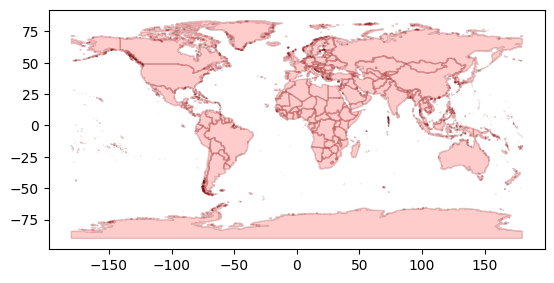

In [11]:
gdf.plot(color='red', edgecolor='maroon', alpha=.2)
plt.show()

# Read local copy using DuckDB

In [12]:
def query(vs, query_polygon):
    # Setup
    db = duckdb.connect(":memory:")
    # db.execute("INSTALL httpfs; LOAD httpfs;")
    db.execute("INSTALL spatial; LOAD spatial;")

    # Create a table view
    filepath = os.path.join(vs.geoparquet_directory, '**')
    db.execute(f"CREATE VIEW tbl AS SELECT * FROM parquet_scan('{filepath}')")
    #cols = [t[0] for t in db.execute("describe tbl").fetchall()]

    # Create a derived table where the geometry column is a true geometry, not just a WKB.
    query = f"""
    CREATE OR REPLACE TABLE tbl2 AS
        SELECT *, ST_GEOMFROMWKB(geometry) as geom
        FROM tbl;
    """
    db.execute(query)
    cols2 = [t[0] for t in db.execute(f"""describe tbl2""").fetchall()]

    # Do the query
    json_string = shapely.to_geojson(query_polygon) # Upstate Ithaca
    query = f"""select * from tbl2 where ST_INTERSECTS(geom, ST_GeomFromGeoJSON('{json_string}'))"""
    gdf = db.execute(query).fetchall()
    gdf = pandas.DataFrame(gdf, columns=cols2)
    gdf['geometry'] = gdf['geometry'].apply(lambda x: wkb.loads(x, hex=True))
    
    return geopandas.GeoDataFrame(gdf)

In [13]:
%%time
#query_polygon = shapely.box(-76.6, 42.3, -76.4, 42.5)
query_polygon = shapely.box(-20, 20, 20, 60)
gdf = query(vs, query_polygon)
gdf = gdf.intersection(query_polygon)

CPU times: total: 62.5 ms
Wall time: 245 ms


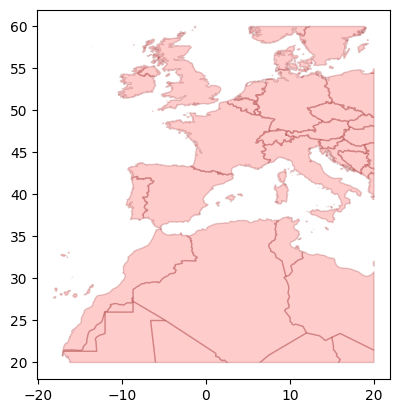

In [14]:
gdf.plot(color='red', edgecolor='maroon', alpha=.2)
plt.show()

# Access credentials

In [15]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# COS upload

In [16]:
def connect_s3(access_key_id, secret_access_key, endpoint_url):
    remote_fs = s3fs.S3FileSystem(
        key=access_key_id,
        secret=secret_access_key,
        client_kwargs={
            'endpoint_url': endpoint_url,
        }
    )
    return remote_fs

def cos_upload(vs, bucket, remote_fs, verbose=True):
    """Push local geoparquet files to COS."""
    local_paths = glob(os.path.join(vs.geoparquet_directory, '**/*.parquet'), recursive=True)
    local_paths = [f.replace('\\', '/') for f in local_paths]

    prefix = os.path.join(bucket, 'vectorstore').replace('\\', '/')
    for local_path in local_paths:
        remote_path = os.path.join(prefix, local_path.lstrip(vs.vectorstore_directory)).replace('\\', '/')
        if verbose:
            print('local_path', local_path)
            print('remote_path', remote_path)
        remote_fs.upload(local_path, remote_path)

In [17]:
# Connect to S3 bucket
remote_fs = connect_s3(access_key_id, secret_access_key, endpoint_url)

In [18]:
# # COS upload
# cos_upload(vs, bucket, remote_fs)

In [19]:
remote_geoparquet_directory = 'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_1_states_provinces/grid=World(4326)/geoparquet'
remote_fs.ls(remote_geoparquet_directory)

['fm-geospatial-cos-dev/vectorstore/ne_10m_admin_1_states_provinces/grid=World(4326)/geoparquet/spatial_partition=0q']

# Read remote folder using geopandas

In [20]:
local_path = vs.geoparquet_directory
prefix = os.path.join(bucket, 'vectorstore').replace('\\', '/')
remote_path = os.path.join(prefix, local_path.lstrip(vs.vectorstore_directory)).replace('\\', '/')
remote_path

'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_0_countries/grid=World(4326)/geoparquet'

In [21]:
remote_filepaths = remote_fs.glob(os.path.join(remote_path, '**.parquet').replace('\\', '/'))
remote_filepath = remote_filepaths[0]
remote_filepath

'fm-geospatial-cos-dev/vectorstore/ne_10m_admin_0_countries/grid=World(4326)/geoparquet/spatial_partition=0q/1462b123051e4d28910a7b5465ec8bd9.parquet'

In [22]:
%%time
gdf = geopandas.read_parquet(
    's3://'+remote_path,
    storage_options={
        'key' : access_key_id,
        'secret' : secret_access_key,
        'client_kwargs' : {'endpoint_url': endpoint_url},
    },
    #columns=['adm1_code', 'name', 'timestamp', 'geometry', '_root'],
    # filters=[
    #     # ('name', '=', 'Utah'),
    #     ('_root', '>=', '0q021'),
    #     ('_root', '<', '0q022'),
    # ]
)

CPU times: total: 46.9 ms
Wall time: 3.11 s


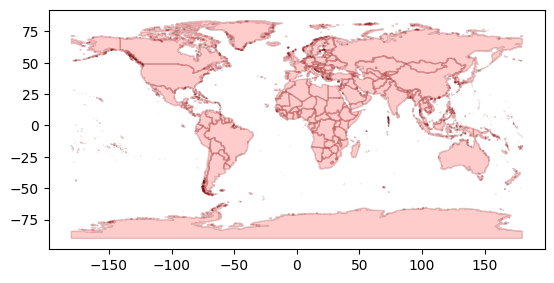

In [23]:
gdf.plot(color='red', edgecolor='maroon', alpha=.2)
plt.show()

# Read remote folder using DuckDB

In [24]:
def query_remote(vs, endpoint_url, access_key_id, secret_access_key, query_polygon):
    s3_endpoint = endpoint_url.split('https://')[1]
    s3_region = 'us-east'

    # Setup
    db = duckdb.connect(":memory:")
    #db.execute("INSTALL aws; LOAD aws;")
    db.execute("INSTALL httpfs; LOAD httpfs;")
    db.execute("INSTALL spatial; LOAD spatial;")

    # Define Connection to Object Storage
    db.execute(f"SET s3_region='{s3_region}'")
    db.execute(f"SET s3_endpoint='{s3_endpoint}'")
    db.execute(f"SET s3_access_key_id='{access_key_id}'")
    db.execute(f"SET s3_secret_access_key='{secret_access_key}'")
    db.execute("SET s3_url_style='path'")
    #db.execute("SET s3_use_ssl=true")

    # Create a table view
    #filepath = 's3://' + os.path.join(vs.geoparquet_directory, '**')
    filepaths = remote_fs.glob(os.path.join(remote_path, '**.parquet').replace('\\', '/'))
    filepath = 's3://' + filepaths[0]
    db.execute(f"CREATE VIEW tbl AS SELECT * FROM parquet_scan('{filepath}')")
    #cols = [t[0] for t in db.execute("describe tbl").fetchall()]

    # Create a derived table where the geometry column is a true geometry, not just a WKB.
    query = f"""
    CREATE OR REPLACE TABLE tbl2 AS
        SELECT *, ST_GEOMFROMWKB(geometry) as geom
        FROM tbl;
    """
    db.execute(query)
    cols2 = [t[0] for t in db.execute(f"""describe tbl2""").fetchall()]

    # Do the query
    json_string = shapely.to_geojson(query_polygon) # Upstate Ithaca
    query = f"""select * from tbl2 where ST_INTERSECTS(geom, ST_GeomFromGeoJSON('{json_string}'))"""
    gdf = db.execute(query).fetchall()
    gdf = pandas.DataFrame(gdf, columns=cols2)
    gdf['geometry'] = gdf['geometry'].apply(lambda x: wkb.loads(x, hex=True))
    
    return geopandas.GeoDataFrame(gdf)

In [25]:
%%time
gdf = query_remote(vs, endpoint_url, access_key_id, secret_access_key, query_polygon)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: total: 1.33 s
Wall time: 3.38 s


<Axes: >

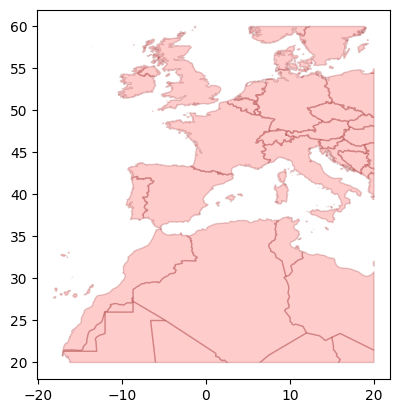

In [26]:
gdf = gdf.intersection(query_polygon)
gdf.plot(color='red', edgecolor='maroon', alpha=.2)